# 📊 Data Visualization Part 1: Matplotlib Masterclass

Welcome to Data Visualization! Humans are terrible at reading massive walls of numbers, but our brains are heavily optimized for identifying visual patterns. **Matplotlib** is the foundational plotting library in Python. While libraries like Seaborn or Plotly are prettier, they are built entirely on top of Matplotlib.

In this notebook, we will master the core chart types, how to format them, and when to use them.

Run the setup cell below to load our libraries and generate the mock datasets we will use for practice.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns # Used later to load standard datasets

# ==========================================
# 🛠️ MOCK DATA SETUP (Run this first!)
# ==========================================

# 1. Line Plot Data (IPL Year-by-Year)
batsman = pd.DataFrame({
    'index': [2015, 2016, 2017, 2018, 2019, 2020],
    'V Kohli': [500, 973, 308, 530, 464, 466],
    'RG Sharma': [482, 489, 333, 286, 405, 332]
})

# 2. Bar Chart Data (Multiple Years)
df_bar = pd.DataFrame({
    'batsman': ['Kohli', 'Rohit', 'Dhoni', 'Rahul', 'Dhawan'],
    '2015': [500, 482, 372, 142, 353],
    '2016': [973, 489, 284, 397, 501],
    '2017': [308, 333, 290, 399, 479]
})

print("✅ Visualization Libraries & Mock Data Loaded Successfully!")


✅ Visualization Libraries & Mock Data Loaded Successfully!


## 1. Types of Data & 2D Line Plots

**Theory:** Before choosing a chart, you must understand your data.

* **Numerical Data:** Numbers with mathematical meaning (Height, Price, Age).
* **Categorical Data:** Labels or groups (Gender, Cities, Colors).

**2D Line Plot (`plt.plot`)**:

* **Used for:** Bivariate Analysis (Analyzing 2 variables). Usually Numerical vs Numerical, or Categorical (Time) vs Numerical.
* **Best Use Case:** Time Series Data (e.g., Stock prices over time, Runs scored per year).

**🧠 Mental Model:** Think of a Line Plot as a connect-the-dots puzzle tracking progress over time.

**💡 Fun Fact:** Matplotlib automatically picks different colors for multiple lines on the same plot, but you can override this using Hex Color Codes (e.g., `#D9F10F`) to match your company's branding exactly!

### 🎯 Practice Tasks

1. Plot a simple line graph comparing `V Kohli` and `RG Sharma` runs over the years using the `batsman` DataFrame.
2. Add a `title`, `xlabel`, and `ylabel`.
3. Give Virat a solid line (`linestyle='solid'`), a diamond marker (`marker='D'`), and label it 'Virat'. Give Rohit a dashed line (`linestyle='dashdot'`), a circle marker (`marker='o'`), and label it 'Rohit'.
4. Turn on the grid (`plt.grid()`) and show the legend (`plt.legend()`).


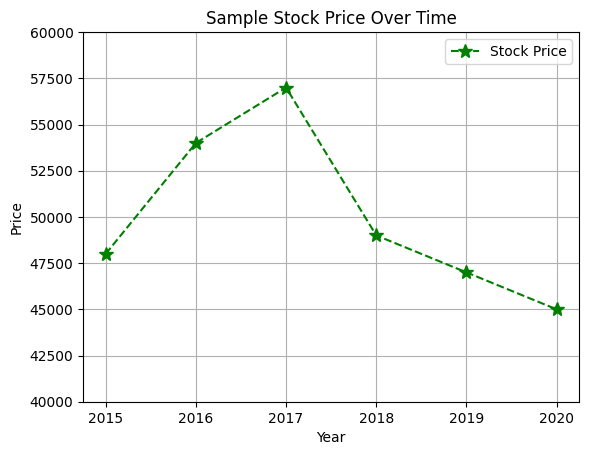

In [2]:
# --- EXAMPLE CODE ---
price = [48000, 54000, 57000, 49000, 47000, 45000]
year = [2015, 2016, 2017, 2018, 2019, 2020]

plt.plot(year, price, color='green', marker='*', markersize=10, linestyle='dashed', label='Stock Price')
plt.title("Sample Stock Price Over Time")
plt.xlabel("Year")
plt.ylabel("Price")
plt.ylim(40000, 60000) # Limiting the Y-axis
plt.grid()
plt.legend(loc='upper right')
plt.show() # Renders the plot and clears the memory

# --- PRACTICE AREA ---
# Task 1, 2, 3, & 4: Create the heavily styled comparison plot for Kohli vs Rohit


## 2. Scatter Plots

**Theory:** * **Used for:** Bivariate Analysis (Numerical vs Numerical).

* **Best Use Case:** Finding **Correlation** or plotting distributions. It plots independent dots without connecting lines.

**🗣️ Interview Question:** *What is the difference between plotting a scatter plot using `plt.scatter(x, y)` vs `plt.plot(x, y, 'o')`?*
**Answer:** `plt.plot` with a circle marker is significantly faster under the hood for massive datasets. However, `plt.scatter` is more powerful because it allows you to dynamically change the size (`s=`) and color (`c=`) of *each individual dot* based on a third variable!

### 🎯 Practice Tasks

1. Load the internal Seaborn dataset: `tips = sns.load_dataset('tips')`.
2. Create a standard scatter plot comparing `total_bill` (X) vs `tip` (Y).
3. **Advanced:** Use `plt.scatter()` but dynamically change the size of the dots based on the table size! Set `s=tips['size'] * 20` so the dots are large enough to see.


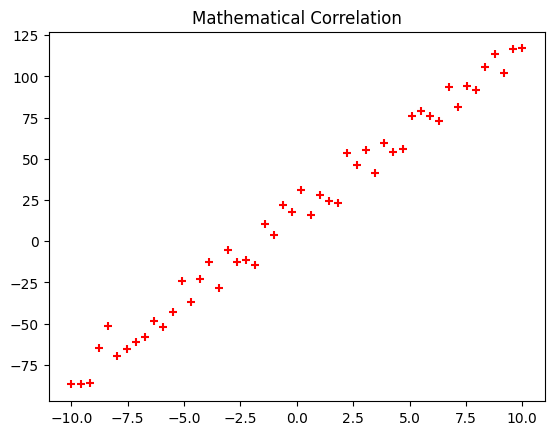

In [3]:
# --- EXAMPLE CODE ---
# Generating fake correlation data
x = np.linspace(-10, 10, 50)
y = 10 * x + 3 + np.random.randint(0, 30, 50)

plt.scatter(x, y, color='red', marker='+')
plt.title("Mathematical Correlation")
plt.show()

# --- PRACTICE AREA ---
# Task 1: Load the tips dataset using sns.load_dataset('tips')


# Task 2 & 3: Create the dynamic scatter plot mapping total_bill vs tip, sizing the dots by the 'size' column


## 3. Bar Charts (Simple, Multiple, Stacked)

**Theory:** * **Used for:** Bivariate Analysis (Categorical vs Numerical).

* **Best Use Case:** Comparing aggregate quantities across different categories.

**📊 Diagram: Bar Chart Types**

```text
Simple Bar        Multiple Bar         Stacked Bar
  |  █              |  █                 |  ▓ (2016)
  |  █              |  █ ▒               |  █ (2015)
--+------         --+------            --+------
   Cat A             Cat A                Cat A

```

**⚠️ The Overlapping Problem:** If your X-axis labels are very long (like full movie names), they will overlap and become unreadable.
**Solution:** Use `plt.xticks(rotation='vertical')` to spin the text 90 degrees!

### 🎯 Practice Tasks

1. Create a simple vertical bar chart using `plt.bar()` with `['A', 'B', 'C']` on the X-axis and `[10, 20, 15]` on the Y-axis.
2. Create a **Stacked Bar Chart** using the `df_bar` mock data. Plot '2015' first. Then plot '2016', but pass the argument `bottom=df_bar['2015']`.
3. Try plotting a multiple-bar chart (side-by-side). *Hint: See the example code below on how we use `np.arange` and offsets to trick Matplotlib into placing bars next to each other!*


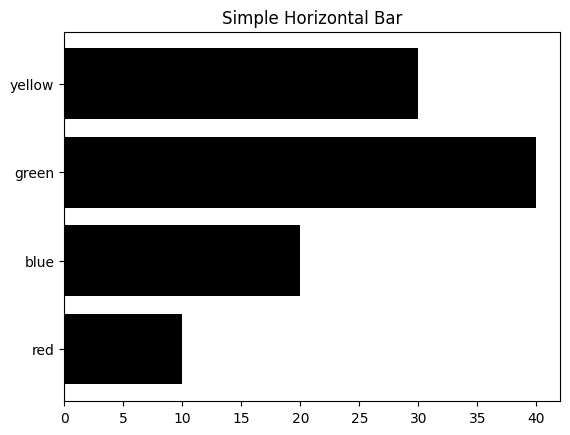

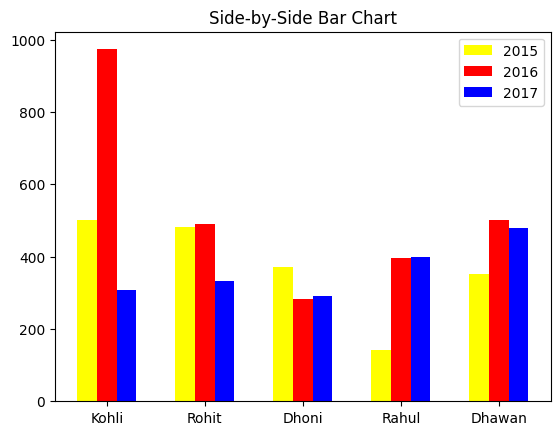

In [4]:
# --- EXAMPLE CODE ---
# Horizontal Bar Chart
children = [10, 20, 40, 30]
colors = ['red', 'blue', 'green', 'yellow']
plt.barh(colors, children, color='black') # Note: barh makes it horizontal!
plt.title("Simple Horizontal Bar")
plt.show()

# SIDE-BY-SIDE BAR CHART (The tricky offset method)
x_indexes = np.arange(df_bar.shape[0]) # Creates [0, 1, 2, 3, 4]
width = 0.2

# We shift the X coordinates left and right by 0.2
plt.bar(x_indexes - 0.2, df_bar['2015'], width=width, color='yellow', label='2015')
plt.bar(x_indexes, df_bar['2016'], width=width, color='red', label='2016')
plt.bar(x_indexes + 0.2, df_bar['2017'], width=width, color='blue', label='2017')

# Replace the numeric indexes [0, 1, 2...] with actual batsman names
plt.xticks(x_indexes, df_bar['batsman'])
plt.legend()
plt.title("Side-by-Side Bar Chart")
plt.show()

# --- PRACTICE AREA ---
# Task 1: Create a simple vertical bar chart with 3 categories


# Task 2: Create a Stacked Bar Chart for 2015 and 2016 using the 'bottom' parameter


## 4. Histograms

**Theory:** * **Used for:** Univariate Analysis (Analyzing 1 Numerical Variable).

* **Best Use Case:** Finding the **Frequency / Distribution** of data. It groups continuous numbers into "bins" (ranges) and counts how many data points fall into each bin.

**🗣️ Interview Question:** *What is the difference between a Bar Chart and a Histogram?*
**Answer:** A Bar Chart compares different *categories* against a numerical value (X-axis has text labels like 'Apple', 'Banana'). A Histogram looks at a *single numerical column* and groups it into continuous mathematical ranges to show distribution (X-axis has ranges like 0-10, 10-20).

### 🎯 Practice Tasks

1. Generate an array of 1000 random numbers representing ages from 1 to 100 using `np.random.randint(1, 100, 1000)`.
2. Plot a histogram of these ages using `plt.hist()`.
3. Explicitly define the bins by passing the argument `bins=[0, 18, 35, 60, 100]` to group the ages into demographic buckets (Kids, Young Adults, Adults, Seniors).



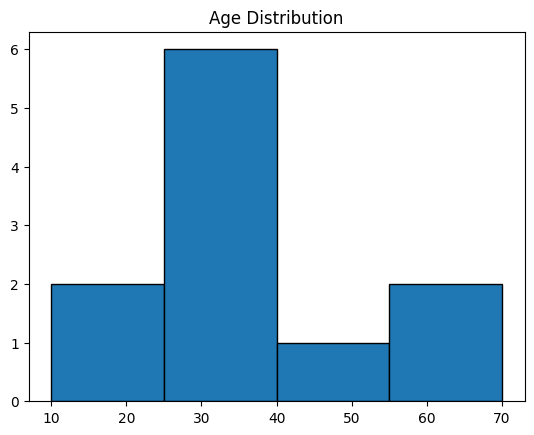

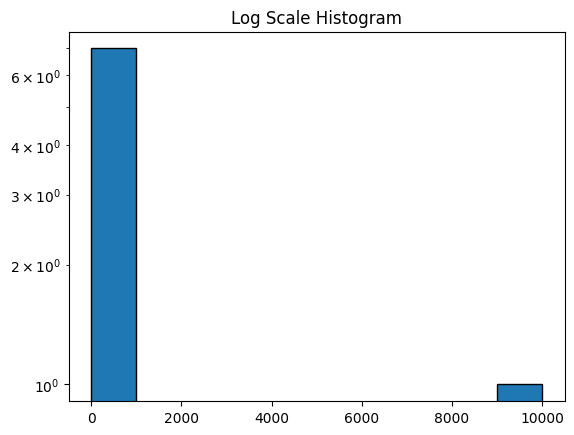

In [5]:
# --- EXAMPLE CODE ---
data = [32, 45, 56, 10, 15, 27, 61, 35, 33, 31, 38]
# If we don't provide bins, Matplotlib decides the ranges automatically.
# Here we force specific ranges:
plt.hist(data, bins=[10, 25, 40, 55, 70], edgecolor='black')
plt.title("Age Distribution")
plt.show()

# Logarithmic Scale (Useful for massively skewed data)
large_variance_data = [1, 2, 2, 3, 10, 100, 1000, 10000]
plt.hist(large_variance_data, log=True, edgecolor='black')
plt.title("Log Scale Histogram")
plt.show()

# --- PRACTICE AREA ---
# Task 1: Generate 1000 random ages between 1 and 100


# Task 2 & 3: Plot the histogram using custom bins for demographic buckets



## 5. Pie Charts

**Theory:** * **Used for:** Univariate / Bivariate Analysis (Categorical vs Numerical).

* **Best Use Case:** Showing the **percentage contribution** of categories to a whole (e.g., Market Share). Avoid Pie Charts if you have more than 5-6 categories, as human eyes are very bad at comparing slice angles.

**Key Parameters:**

* `autopct='%0.1f%%'`: Automatically calculates and stamps the percentage inside the slice (to 1 decimal place).
* `explode`: A list of numbers dictating how far to "pull out" a slice to highlight it.
* `shadow=True`: Adds a 3D drop shadow.

### 🎯 Practice Tasks

1. Use the `df_bar` DataFrame. Calculate the total runs Kohli scored across all 3 years, and compare it to Rohit.
2. Create a Pie Chart comparing Kohli's total runs to Rohit's total runs.
3. Pass labels, `autopct` for percentages, and use `explode` to pop out Kohli's slice.


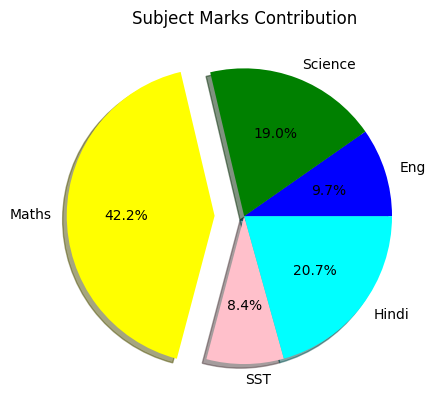

In [6]:
# --- EXAMPLE CODE ---
data = [23, 45, 100, 20, 49]
subjects = ['Eng', 'Science', 'Maths', 'SST', 'Hindi']

# The explode array must have the exact same length as the data!
# 0 means don't move, 0.2 means pull out by 20%
pop_out = [0, 0, 0.2, 0, 0] 

plt.pie(data, labels=subjects, autopct='%0.1f%%', explode=pop_out, shadow=True, colors=['blue','green','yellow','pink','cyan'])
plt.title("Subject Marks Contribution")
plt.show()

# --- PRACTICE AREA ---
# Task 1: Calculate total runs for Kohli and Rohit (summing 2015, 2016, 2017)


# Task 2 & 3: Create a Pie chart comparing the two, exploding Kohli's slice.



## 6. Changing Styles & Saving Figures

**Theory:** You do not have to settle for the default white background and basic colors. Matplotlib comes with pre-installed themes.

* `plt.style.available`: Prints a list of all installed themes.
* `plt.style.use('theme_name')`: Activates the theme for all subsequent plots.
* `plt.savefig('filename.png')`: Saves your final chart as an image file on your machine. *Crucial: Call this BEFORE `plt.show()`!*

### 🎯 Practice Tasks

1. Run `plt.style.available` to see your options.
2. Activate `'dark_background'` using `plt.style.use()`.
3. Create a quick Line Plot and save it to your Colab environment as `'my_dark_plot.png'`.

---


Available Styles:
 ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh'] ...and more!


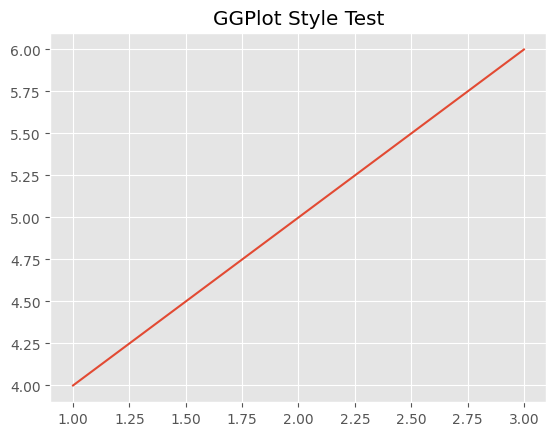

In [7]:
# --- EXAMPLE CODE ---
# View all available styles
print("Available Styles:\n", plt.style.available[:5], "...and more!")

# Set a style
plt.style.use('ggplot')

plt.plot([1, 2, 3], [4, 5, 6])
plt.title("GGPlot Style Test")
# Saving the figure (It will appear in your left-hand Colab file explorer)
plt.savefig('ggplot_test.png')
plt.show()

# --- PRACTICE AREA ---
# Task 1 & 2: Set the style to 'dark_background'


# Task 3: Create a simple plot and save it as 'my_dark_plot.png'
